# Regularization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
def create_data(number_of_points):
    x = []
    y = []

    for i in range(number_of_points):
        x.append(np.random.uniform(low=0.0, high=2.0, size=None))
        y.append(x[-1]**2 + np.random.normal(loc=0.0, scale=0.3, size=None))
        
    return x,y

In [3]:
# Ya da aşağıdaki gibi vektörel de yaratabilirdik veriyi
"""
number_of_points = 20

x = np.random.uniform(low=0.0, high=2.0, size=number_of_points)

y = x**2 + np.random.normal(loc=0.0, scale=0.3, size=number_of_points)

"""

'\nnumber_of_points = 20\n\nx = np.random.uniform(low=0.0, high=2.0, size=number_of_points)\n\ny = x**2 + np.random.normal(loc=0.0, scale=0.3, size=number_of_points)\n\n'

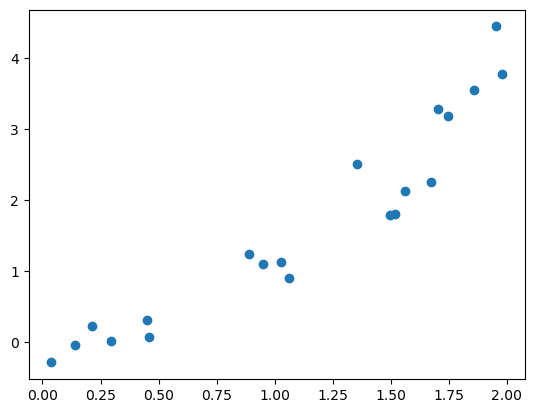

In [28]:
x,y = create_data(20)

plot_ = plt.scatter(x, y)

In [29]:
poli_veri = pd.DataFrame(data=[x, y]).T

poli_veri.columns = ['x', 'y']

poli_veri.head()

,x,y
0,0.451738,0.305928
1,0.295194,0.010868
2,1.953288,4.445011
3,1.746689,3.183166
4,1.701742,3.281324


In [30]:
polinom_derecesi = 20

for i in range(2, polinom_derecesi+1):
    poli_veri["x" + str(i)] = poli_veri["x"] ** i

poli_veri.head()

,x,y,x2,x3,x4,x5,x6,x7,x8,x9,...,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20
0,0.451738,0.305928,0.204067,0.092185,0.041643,0.018812,0.008498,0.003839,0.001734,0.000783,...,0.000160,7.221634e-05,3.262284e-05,1.473696e-05,6.657242e-06,3.007327e-06,1.358523e-06,6.136958e-07,2.772295e-07,1.252350e-07
1,0.295194,0.010868,0.087139,0.025723,0.007593,0.002241,0.000662,0.000195,0.000058,0.000017,...,0.000001,4.378123e-07,1.292395e-07,3.815071e-08,1.126186e-08,3.324431e-09,9.813517e-10,2.896890e-10,8.551442e-11,2.524333e-11
2,1.953288,4.445011,3.815334,7.452445,14.556771,28.433565,55.538938,108.483536,211.899578,413.900884,...,1579.169972,3.084574e+03,6.025060e+03,1.176868e+04,2.298762e+04,4.490143e+04,8.770542e+04,1.713139e+05,3.346255e+05,6.536198e+05
3,1.746689,3.183166,3.050921,5.329009,9.308118,16.258383,28.398332,49.603041,86.641063,151.334953,...,461.710965,8.064653e+02,1.408644e+03,2.460462e+03,4.297660e+03,7.506674e+03,1.311182e+04,2.290227e+04,4.000313e+04,6.987301e+04
4,1.701742,3.281324,2.895925,4.928117,8.386382,14.271457,24.286335,41.329070,70.331406,119.685892,...,346.601377,5.898260e+02,1.003732e+03,1.708092e+03,2.906732e+03,4.946507e+03,8.417677e+03,1.432471e+04,2.437696e+04,4.148329e+04


In [31]:
y = np.array(poli_veri['y'])

X = np.array(poli_veri.drop(['y'], axis=1, inplace=False))

In [32]:
lineer = LinearRegression() # model objesinin yaratılması

lineer.fit(X, y)# modelin eğitim verisi kullanılarak uydurulması
lineer_egitim_r2 = lineer.score(X, y)# modelin eğitim verisi üzerinde R^2 değeri

print("Katsayilar:", lineer.intercept_, lineer.coef_)
print('\nLineer: Egitim verisi R2 degeri ', lineer_egitim_r2)

Katsayilar: -2.8046958749702284 [ 1.82272766e+02 -4.90170466e+03  6.29346171e+04 -4.39366214e+05
  1.79561039e+06 -4.37218681e+06  5.91050468e+06 -2.67631344e+06
 -3.77665604e+06  5.28548853e+06  9.52847405e+05 -6.05508646e+06
  2.63937124e+06  4.54177656e+06 -7.44148960e+06  5.33391384e+06
 -2.26300275e+06  5.87688940e+05 -8.69613898e+04  5.64970486e+03]

Lineer: Egitim verisi R2 degeri  0.990197709444232


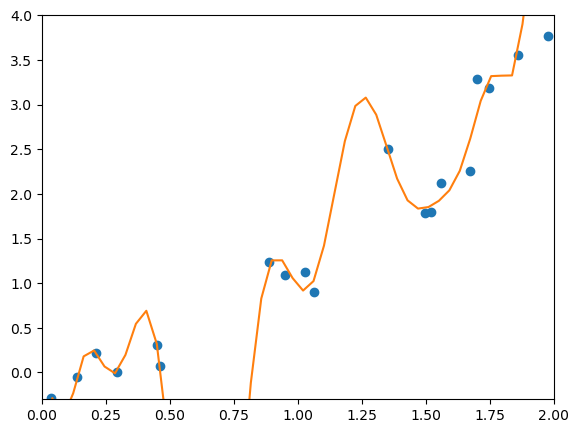

In [33]:
def polinom(x, sabit_terim, katsayilar):

    toplam = sabit_terim

    for i in range(len(katsayilar)):
        toplam += katsayilar[i] * (x**(i+1))

    return toplam

x_lineer = np.linspace(0, 2, 50)
y_lineer = []
for i in range(len(x_lineer)):
    y_lineer.append(polinom(x_lineer[i], lineer.intercept_, lineer.coef_))

fig= plt.figure()
axes= fig.add_axes([0,0,0.8,0.8])
axes.plot(x, y, 'o')

axes.plot(x_lineer, y_lineer)

axes.set_xlim([0,2])
axes.set_ylim([-0.3,4])

plt.show()

In [48]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha = 0.1) # Ridge model objesinin yaratılması, lambda = 0.001 

ridge.fit(X, y) # modelin eğitim verisi kullanılarak uydurulması
ridge_egitim_r2 = ridge.score(X, y)

print("Ridge: Katsayilar", ridge.intercept_, ridge.coef_)
print('\nRidge: Egitim verisi R2 degeri ', ridge_egitim_r2)

Ridge: Katsayilar -0.10672020896085854 [ 0.52221765  0.17769391  0.05389804  0.04743169  0.10248513  0.17837062
  0.23510719  0.23640536  0.15993654  0.01091638 -0.16647766 -0.28990844
 -0.26610129 -0.05539303  0.24001891  0.34208596 -0.00713822 -0.45875149
  0.27733281 -0.04775433]

Ridge: Egitim verisi R2 degeri  0.9648905832147837


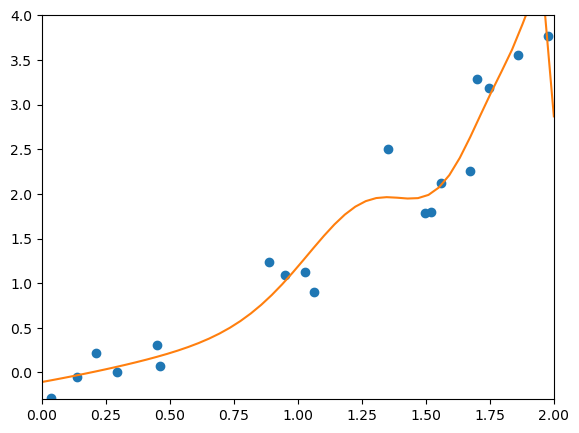

In [49]:
x_ridge = np.linspace(0, 2, 50)
y_ridge = []
for i in range(len(x_ridge)):
    y_ridge.append(polinom(x_ridge[i], ridge.intercept_, ridge.coef_))

fig= plt.figure()
axes= fig.add_axes([0,0,0.8,0.8])
axes.plot(x, y, 'o')

axes.plot(x_ridge, y_ridge)

axes.set_xlim([0,2])
axes.set_ylim([-0.3,4])

plt.show()

In [42]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha = 0.1) # Lasso model objesinin yaratılması, lambda = 0.01 

lasso.fit(X, y)
lasso_egitim_r2 = lasso.score(X, y)

print("Lasso: Katsayilar", lasso.intercept_, lasso.coef_)
print('\nLasso: Egitim verisi R2 degeri ', lasso_egitim_r2)

Lasso: Katsayilar 0.3570572309367681 [ 0.00000000e+00  0.00000000e+00  2.69611913e-01  1.24533497e-01
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -1.16578251e-04  1.49365350e-04  2.08746555e-04
  8.08847287e-05  2.58309985e-05  5.30997322e-06 -1.48142357e-06
 -2.77213849e-06 -2.24469572e-06 -1.53206278e-06 -9.57041665e-07]

Lasso: Egitim verisi R2 degeri  0.915596525563011


/Users/ozgur/opt/anaconda3/envs/xai/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.421e+00, tolerance: 3.931e-03
  model = cd_fast.enet_coordinate_descent(


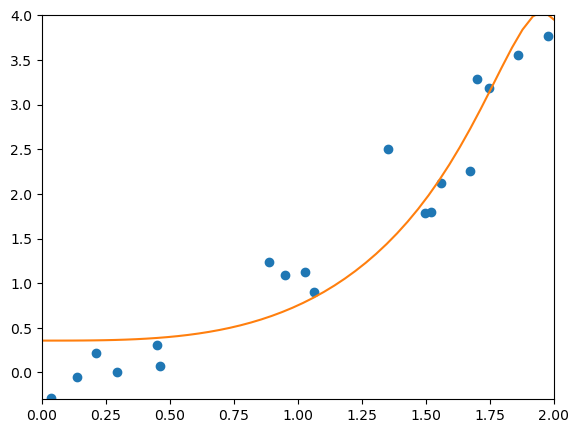

In [39]:
x_lasso = np.linspace(0, 2, 50)
y_lasso = []
for i in range(len(x_lasso)):
    y_lasso.append(polinom(x_lasso[i], lasso.intercept_, lasso.coef_))

fig= plt.figure()
axes= fig.add_axes([0,0,0.8,0.8])
axes.plot(x, y, 'o')

axes.plot(x_lasso, y_lasso)

axes.set_xlim([0,2])
axes.set_ylim([-0.3,4])

plt.show()

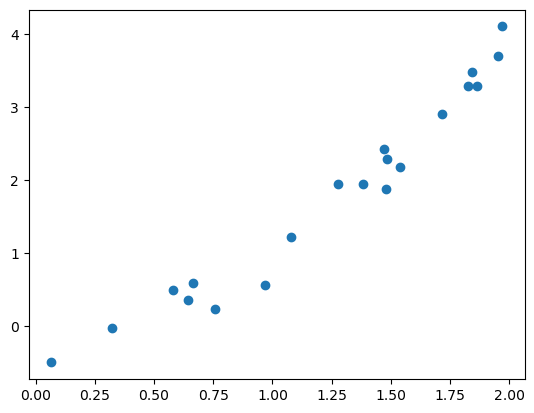

In [14]:
# Ustteki veri y = x ** 2 + e (gurultu) formuluyle olusturulmustu. 
# Ayni formul ile yeni veri olusturalim

x2,y2 = create_data(20)

poli_veri = pd.DataFrame(data=[x2, y2]).T

poli_veri.columns = ['x', 'y']

for i in range(2, polinom_derecesi+1):
    poli_veri["x" + str(i)] = poli_veri["x"] ** i
    
y2 = np.array(poli_veri['y'])

X2 = np.array(poli_veri.drop(['y'], axis=1, inplace=False))

plot_ = plt.scatter(x2, y2)

-25244899.526551154


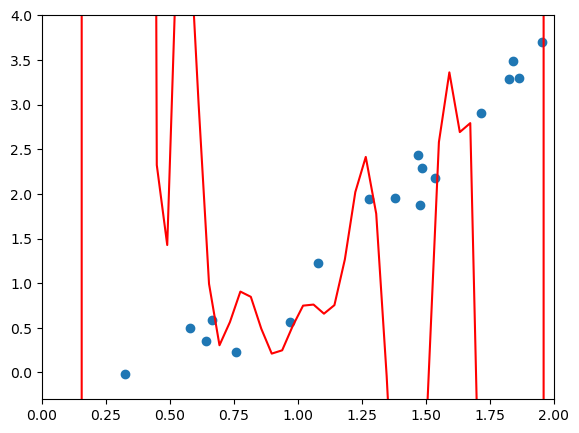

In [15]:
print(lineer.score(X2, y2))

fig= plt.figure()

axes= fig.add_axes([0.1,0.1,0.8,0.8])


axes.scatter(x2, y2)

axes.plot(x_lineer, y_lineer, color='red')


axes.set_xlim([0,2])

axes.set_ylim([-0.3,4])

plt.show()

-72.33908868016948


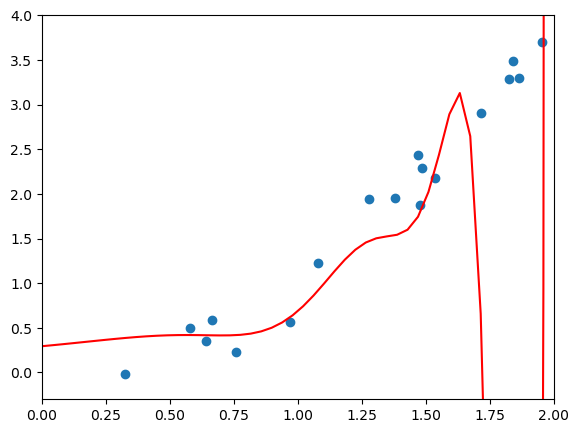

In [16]:
print(ridge.score(X2, y2))

fig= plt.figure()

axes= fig.add_axes([0.1,0.1,0.8,0.8])


axes.scatter(x2, y2)

axes.plot(x_ridge, y_ridge, color='red')


axes.set_xlim([0,2])

axes.set_ylim([-0.3,4])

plt.show()

0.956978707283362


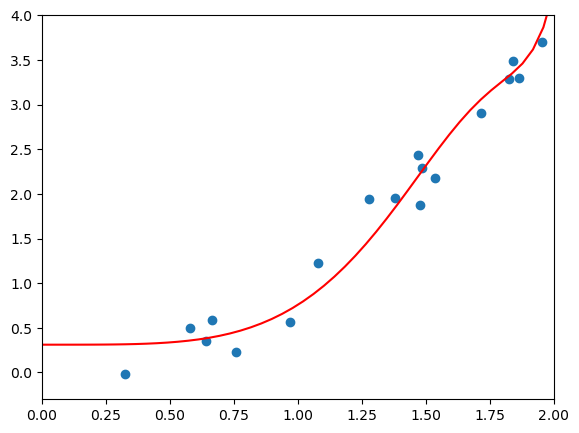

In [17]:
print(lasso.score(X2, y2))

fig= plt.figure()

axes= fig.add_axes([0.1,0.1,0.8,0.8])


axes.scatter(x2, y2)

axes.plot(x_lasso, y_lasso, color='red')


axes.set_xlim([0,2])

axes.set_ylim([-0.3,4])

plt.show()

# Feature Subset Selection

In [18]:
def create_data(number_of_points):
    x = []
    y = []

    for i in range(number_of_points):
        x.append(np.random.uniform(low=0.0, high=1.0, size=None))
        y.append(x[-1]**3 - x[-1]**8 + np.random.normal(loc=0.0, scale=0.02, size=None))
        
    return x,y

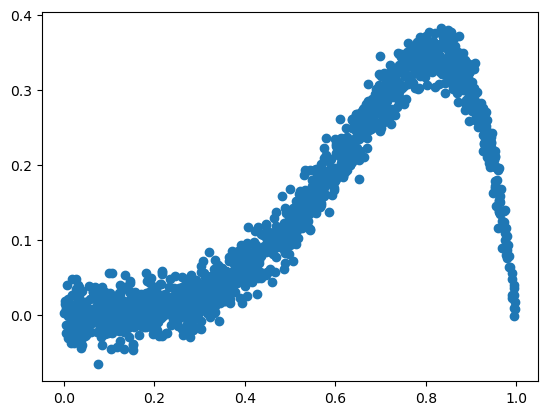

In [19]:
x,y = create_data(1500)

plot_ = plt.scatter(x, y)

In [20]:
poli_veri = pd.DataFrame(data=[x, y]).T

poli_veri.columns = ['x', 'y']

poli_veri.head()

,x,y
0,0.899182,0.275417
1,0.257410,0.028468
2,0.294391,0.034199
3,0.515630,0.151595
4,0.143990,-0.029255


In [21]:
polinom_derecesi = 15

for i in range(2, polinom_derecesi+1):
    poli_veri["x" + str(i)] = poli_veri["x"] ** i

y = np.array(poli_veri['y'])

poli_veri_girdi = poli_veri.drop(['y'], axis=1, inplace=False).copy()

X = np.array(poli_veri_girdi)

poli_veri_girdi.head()

,x,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15
0,0.899182,0.808528,0.727013,0.653717,0.587810,0.528548,0.475261,4.273457e-01,3.842614e-01,3.455208e-01,3.106860e-01,2.793631e-01,2.511982e-01,2.258728e-01,2.031006e-01
1,0.257410,0.066260,0.017056,0.004390,0.001130,0.000291,0.000075,1.927538e-05,4.961674e-06,1.277184e-06,3.287600e-07,8.462609e-08,2.178360e-08,5.607316e-09,1.443379e-09
2,0.294391,0.086666,0.025514,0.007511,0.002211,0.000651,0.000192,5.641573e-05,1.660830e-05,4.889341e-06,1.439380e-06,4.237409e-07,1.247456e-07,3.672404e-08,1.081124e-08
3,0.515630,0.265874,0.137093,0.070689,0.036449,0.018794,0.009691,4.996946e-03,2.576575e-03,1.328559e-03,6.850446e-04,3.532295e-04,1.821357e-04,9.391460e-05,4.842517e-05
4,0.143990,0.020733,0.002985,0.000430,0.000062,0.000009,0.000001,1.847857e-07,2.660737e-08,3.831206e-09,5.516570e-10,7.943331e-11,1.143763e-11,1.646910e-12,2.371392e-13


In [22]:
X_egitim, X_dogrulama, y_egitim, y_dogrulama = train_test_split(X, y, test_size = 0.5, random_state = 3)

oznitelik_sayisi = len(X_egitim[0])

lineerModel = LinearRegression()

print("Egitim verisinin uzunlugu:", len(X_egitim))
print("Dogrulama verisinin uzunlugu:", len(X_dogrulama))
#print("Test verisinin uzunlugu:", len(X_test))
print("Oznitelik sayisi:", oznitelik_sayisi)

Egitim verisinin uzunlugu: 750
Dogrulama verisinin uzunlugu: 750
Oznitelik sayisi: 15


In [23]:
import itertools 

for kombinasyon in itertools.combinations(range(oznitelik_sayisi), 2):
    print(kombinasyon, end=" ")

(0, 1) (0, 2) (0, 3) (0, 4) (0, 5) (0, 6) (0, 7) (0, 8) (0, 9) (0, 10) (0, 11) (0, 12) (0, 13) (0, 14) (1, 2) (1, 3) (1, 4) (1, 5) (1, 6) (1, 7) (1, 8) (1, 9) (1, 10) (1, 11) (1, 12) (1, 13) (1, 14) (2, 3) (2, 4) (2, 5) (2, 6) (2, 7) (2, 8) (2, 9) (2, 10) (2, 11) (2, 12) (2, 13) (2, 14) (3, 4) (3, 5) (3, 6) (3, 7) (3, 8) (3, 9) (3, 10) (3, 11) (3, 12) (3, 13) (3, 14) (4, 5) (4, 6) (4, 7) (4, 8) (4, 9) (4, 10) (4, 11) (4, 12) (4, 13) (4, 14) (5, 6) (5, 7) (5, 8) (5, 9) (5, 10) (5, 11) (5, 12) (5, 13) (5, 14) (6, 7) (6, 8) (6, 9) (6, 10) (6, 11) (6, 12) (6, 13) (6, 14) (7, 8) (7, 9) (7, 10) (7, 11) (7, 12) (7, 13) (7, 14) (8, 9) (8, 10) (8, 11) (8, 12) (8, 13) (8, 14) (9, 10) (9, 11) (9, 12) (9, 13) (9, 14) (10, 11) (10, 12) (10, 13) (10, 14) (11, 12) (11, 13) (11, 14) (12, 13) (12, 14) (13, 14) 

In [24]:
secili_sutunlar = []
maks_r2 = 0


for i in range(oznitelik_sayisi):
    for kombinasyon in itertools.combinations(range(oznitelik_sayisi), i+1):
        
        lineerModel.fit(X_egitim[:, list(kombinasyon)], y_egitim)
        lineer_test_r2 = lineerModel.score(X_dogrulama[:, list(kombinasyon)], y_dogrulama).round(3)
        
        if lineer_test_r2 > maks_r2:
            maks_r2 = lineer_test_r2
            secili_sutunlar = list(kombinasyon)

print("SONUC:", secili_sutunlar, maks_r2)

SONUC: [2, 7] 0.977


In [25]:
secili_sutunlar = []

kalan_sutunlar = list(range(oznitelik_sayisi))
maks_r2 = 0

for j in range(oznitelik_sayisi):

    en_iyi_oznitelik = np.nan

    for i in kalan_sutunlar:

        deneme_sutunlari = secili_sutunlar + [i]

        lineerModel.fit(X_egitim[:, deneme_sutunlari], y_egitim)

        lineer_test_r2 = lineerModel.score(X_dogrulama[:, deneme_sutunlari], y_dogrulama).round(3)

        if lineer_test_r2 > maks_r2:
            maks_r2 = lineer_test_r2
            en_iyi_oznitelik = i

    if not np.isnan(en_iyi_oznitelik):
        kalan_sutunlar.remove(en_iyi_oznitelik)
        secili_sutunlar += [en_iyi_oznitelik]

    print("SONUC:", secili_sutunlar, maks_r2)

SONUC: [0] 0.775
SONUC: [0, 14] 0.899
SONUC: [0, 14, 1] 0.968
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977
SONUC: [0, 14, 1, 8] 0.977


In [26]:
from sklearn.datasets import load_boston

boston = load_boston()

X_egitim1, X_test, y_egitim1, y_test = train_test_split(X, y, test_size = 0.2, random_state = 3)
X_egitim, X_dogrulama, y_egitim, y_dogrulama = train_test_split(X_egitim1, y_egitim1, test_size = 0.25, random_state = 3)

oznitelik_sayisi = len(X_egitim[0])


lineerModel = LinearRegression()

print("Egitim verisinin uzunlugu:", len(X_egitim))
print("Dogrulama verisinin uzunlugu:", len(X_dogrulama))
print("Test verisinin uzunlugu:", len(X_test))
print("Oznitelik sayisi:", oznitelik_sayisi)

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [ ]:
# En iyi tek öznitelikli (feature) modeli bulalım.

maks_r2 = 0
en_iyi_oznitelik = np.nan

for i in range(oznitelik_sayisi):

    lineerModel.fit(X_egitim[:, [i]], y_egitim)

    lineer_test_r2 = lineerModel.score(X_dogrulama[:, [i]], y_dogrulama)
    print(i, lineer_test_r2)

    if lineer_test_r2 > maks_r2:
        maks_r2 = lineer_test_r2
        en_iyi_oznitelik = i

print("\nSONUC:", en_iyi_oznitelik, maks_r2)

0 0.7206409691051607
1 0.6222421199730018
2 0.48614616644328756
3 0.36706019145663205
4 0.27302877003324555
5 0.20095612844813682
6 0.14613099589343248
7 0.10442805680987921
8 0.07262933704058594
9 0.04831107034274418
10 0.029665130825234032
11 0.015342496828513186
12 0.004332522140111705
13 -0.004126286318450134
14 -0.010611282431748803

SONUC: 0 0.7206409691051607


In [ ]:
secili_sutunlar = []
kalan_sutunlar = list(range(oznitelik_sayisi))
maks_r2 = 0

for j in range(oznitelik_sayisi):

    en_iyi_oznitelik = np.nan

    for i in kalan_sutunlar:

        deneme_sutunlari = secili_sutunlar + [i]

        lineerModel.fit(X_egitim[:, deneme_sutunlari], y_egitim)

        lineer_test_r2 = lineerModel.score(X_dogrulama[:, deneme_sutunlari], y_dogrulama).round(2)

        if lineer_test_r2 > maks_r2:
            maks_r2 = lineer_test_r2
            en_iyi_oznitelik = i

    if not np.isnan(en_iyi_oznitelik):
        kalan_sutunlar.remove(en_iyi_oznitelik)
        secili_sutunlar += [en_iyi_oznitelik]

    print("SONUC:", secili_sutunlar, maks_r2)
        

SONUC: [0] 0.72
SONUC: [0, 13] 0.91
SONUC: [0, 13, 1] 0.97
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98
SONUC: [0, 13, 1, 5] 0.98


In [ ]:
import itertools 

secili_sutunlar = []
maks_r2 = 0

for i in range(oznitelik_sayisi):
    for kombinasyon in itertools.combinations(range(oznitelik_sayisi), i+1):
        
        lineerModel.fit(X_egitim[:, list(kombinasyon)], y_egitim)
        lineer_test_r2 = lineerModel.score(X_dogrulama[:, list(kombinasyon)], y_dogrulama).round(2)
        
        if lineer_test_r2 > maks_r2:
            maks_r2 = lineer_test_r2
            secili_sutunlar = list(kombinasyon)

    print(secili_sutunlar, maks_r2)

print("SONUC:", secili_sutunlar, maks_r2)

[0] 0.72
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
[2, 6] 0.98
SONUC: [2, 6] 0.98


In [ ]:
# Raporlanacak skor

lineerModel.fit(X_egitim1[:, secili_sutunlar], y_egitim1)

lineerModel.score(X_test[:, secili_sutunlar], y_test)


0.9754757864770313

In [ ]:
# Nihayi kullanıma sunulacak model

model = lineerModel.fit(X[:, secili_sutunlar], y)

# Cross-Validation with LightGBM

In [144]:
# Kodlar http://www.veridefteri.com/2018/05/22/lightgbme-giris/ adresinden alınıp değiştirilmiştir

import pandas as pd

# Veri kümesini ikiye bölmek ve performans ölçütlerinin hesaplanması için gerekli modüller.
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

# Grafik çizdirmek için gerekli paket.
import matplotlib.pyplot as plt

# LightGBM paketi.
import lightgbm as lgb

import numpy as np

#Uyarı mesajlarını kapatmak için
import warnings
warnings.filterwarnings("ignore")

In [146]:
df = pd.read_csv(r"C:\Users\HP_Rukiye\My Drive\Academic\1. Okul Isleri\8) Galatasaray\Machine Learning\Course_materials\Course_Data\bank-additional-full.csv", sep=";")
y = (df['y'] == 'yes') * 1

df.drop('y', axis=1, inplace = True)

df.columns = ['yas', 'is', 'medeni_durum', 'egitim', 'gecikme', 'ev', 'borc', 'iletisim', 'ay', 'haftanin_gunu',
              'sure', 'kampanya', 'onceki_iletisimden_sonra_gecen_gun', 'iletisim_sayısı', 'iletisim_sonucu', 
              'issizlik', 'tuketici_fiyat_endeksi', 'tuketici_guven_endeksi', 'euribor_faizi', 'calısan_sayısı'] 


# "sure" değişkenini sağlıklı bir analiz için veri kümesinden çıkarıyoruz.

df.drop('sure', inplace = True, axis=1)

df.head()

,yas,is,medeni_durum,egitim,gecikme,ev,borc,iletisim,ay,haftanin_gunu,kampanya,onceki_iletisimden_sonra_gecen_gun,iletisim_sayısı,iletisim_sonucu,issizlik,tuketici_fiyat_endeksi,tuketici_guven_endeksi,euribor_faizi,calısan_sayısı
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


In [152]:
# Kategorik sutunlardaki degerleri (metinleri) numrik degerlere donusturelim

from sklearn.preprocessing import LabelEncoder

kategorik_sutunlar = ['is', 'medeni_durum', 'egitim', 'gecikme', 'ev', 'borc', 'iletisim', 'ay',
                      'haftanin_gunu', 'iletisim_sonucu']

for i in kategorik_sutunlar:
    le = LabelEncoder()
    df[i] = le.fit_transform(df[i])

df.head()

,yas,is,medeni_durum,egitim,gecikme,ev,borc,iletisim,ay,haftanin_gunu,kampanya,onceki_iletisimden_sonra_gecen_gun,iletisim_sayısı,iletisim_sonucu,issizlik,tuketici_fiyat_endeksi,tuketici_guven_endeksi,euribor_faizi,calısan_sayısı
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0


In [153]:
# Verisi egitim ve test verisi olarak ikiye ayiralim

df_train, df_test, y_train, y_test = train_test_split(df, y, train_size = 0.7, test_size = 0.3)

print(len(df_train), len(df_test))

28831 12357


In [154]:
lgb_train = lgb.Dataset(data=df_train, label=y_train,  free_raw_data=False)

In [155]:
# Eğitim parametrelerini belirleyelim

params = {
    'task': 'train',
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'auc',
    'num_leaves': 7,
    'learning_rate': 0.05,
    'verbose': -1
}

# Kategorik değişkenlerin indeksleri
kategorik_indeks = [1,2,3,4,5,6,7,8,9,13]
print('Kategorik değişkenler: ' + str(df_train.columns[kategorik_indeks].values))

Kategorik değişkenler: ['is' 'medeni_durum' 'egitim' 'gecikme' 'ev' 'borc' 'iletisim' 'ay'
 'haftanin_gunu' 'iletisim_sonucu']


In [157]:
gbm = lgb.train(params,
                lgb_train,
                categorical_feature = kategorik_indeks,
                num_boost_round = 2000)

# Tahmin ve değerlendirme
y_pred = gbm.predict(df_test)

print('Eğri altı alan değeri:', roc_auc_score(y_test, y_pred))

print('İsabetlilik değeri:', accuracy_score(y_test, (y_pred >= 0.5)*1))

Eğri altı alan değeri: 0.7919158211087363
İsabetlilik değeri: 0.8968196164117505


In [158]:
cv_results = lgb.cv(params,
                    lgb_train,
                    categorical_feature = kategorik_indeks,
                    num_boost_round= 2000,
                    early_stopping_rounds= 25,
                    nfold=10,
                    )

print(len(cv_results['auc-mean']))

165


In [159]:
num_boost_round = len(cv_results['auc-mean'])

gbm = lgb.train(params,
                lgb_train,
                categorical_feature = kategorik_indeks,
                num_boost_round = num_boost_round)

# Tahmin ve değerlendirme
y_pred = gbm.predict(df_test)

print('Eğri altı alan değeri:', roc_auc_score(y_test, y_pred))

print('İsabetlilik değeri:', accuracy_score(y_test, (y_pred>= 0.5)*1))

Eğri altı alan değeri: 0.8007216732565952
İsabetlilik değeri: 0.8990855385611395


In [160]:
max_auc = 0
max_iteration = 0
max_leaves = 0

for i in [3,7,15,31,63,127,255]:

    print(i, end=' : ')

    params['num_leaves'] = i

    cv_results = lgb.cv(params,
                    lgb_train,
                    categorical_feature = kategorik_indeks,
                    num_boost_round= 2000,
                    early_stopping_rounds= 25,
                    nfold=10,
                    )
    
    print(len(cv_results['auc-mean']), cv_results['auc-mean'][-1])
    
    if cv_results['auc-mean'][-1] > max_auc:
        max_auc = cv_results['auc-mean'][-1]
        max_iteration = len(cv_results['auc-mean'])
        max_leaves = i

print('Eğitim bitti...')

3 : 495 0.8016914639054047
7 : 165 0.8034068286905469
15 : 68 0.8058033485547531
31 : 56 0.8069680841816502
63 : 40 0.8067677941209033
127 : 25 0.8057596496374781
255 : 31 0.8000937635752029
Eğitim bitti...


In [161]:
print(max_leaves, max_iteration, max_auc)

31 56 0.8069680841816502


In [162]:
params['num_leaves'] = max_leaves
num_boost_round = max_iteration

print('Eğitim...')

gbm = lgb.train(params,
                lgb_train,
                categorical_feature = kategorik_indeks,
                num_boost_round = num_boost_round)


print('Eğitim bitti...')

# Tahmin ve değerlendirme
y_pred = gbm.predict(df_test)

print('Eğri altı alan değeri:', roc_auc_score(y_test, y_pred))

print('İsabetlilik değeri:', accuracy_score(y_test, (y_pred>= 0.5)*1))

Eğitim...
Eğitim bitti...
Eğri altı alan değeri: 0.8024268026322258
İsabetlilik değeri: 0.8978716516953953


In [163]:
max_auc = 0
max_iteration = 0
max_leaves = 0
max_lr = 0

for i in [7,15,31,63,127]:

    print(i)

    for lr in [0.01, 0.02, 0.03, 0.04, 0.05]:
        print(lr, end=' ')
        if lr == 0.05:
            print()

        params['num_leaves'] = i
        params['learning_rate'] = lr

        cv_results = lgb.cv(params,
                        lgb_train,
                        categorical_feature = kategorik_indeks,
                        num_boost_round= 2000,
                        early_stopping_rounds= 25,
                        nfold=10,
                        )
        
        if cv_results['auc-mean'][-1] > max_auc:
            max_auc = cv_results['auc-mean'][-1]
            max_iteration = len(cv_results['auc-mean'])
            max_leaves = i
            max_lr = lr

print('Eğitim bitti...')

7
0.01 0.02 0.03 0.04 0.05 
15
0.01 0.02 0.03 0.04 0.05 
31
0.01 0.02 0.03 0.04 0.05 
63
0.01 0.02 0.03 0.04 0.05 
127
0.01 0.02 0.03 0.04 0.05 
Eğitim bitti...


In [164]:
print(max_leaves, max_iteration, max_lr, max_auc)

63 100 0.02 0.8075180495717383


In [165]:
params['num_leaves'] = max_leaves
params['learning_rate'] = max_lr
num_boost_round = max_iteration

print('Eğitim...')

gbm = lgb.train(params,
                lgb_train,
                categorical_feature = kategorik_indeks,
                num_boost_round = num_boost_round)


print('Eğitim bitti...')

# Tahmin ve değerlendirme
y_pred = gbm.predict(df_test)

print('Eğri altı alan değeri:', roc_auc_score(y_test, y_pred))

print('İsabetlilik değeri:', accuracy_score(y_test, (y_pred>= 0.5)*1))

Eğitim...
Eğitim bitti...
Eğri altı alan değeri: 0.8019983337248013
İsabetlilik değeri: 0.8973051711580481
